In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import warnings

import pandas as pd


# Load configuration
sys.path.append("../")

from utils import RANDOM_STATE, TEST_SIZE

warnings.filterwarnings("ignore")


# Load the data
X = pd.read_csv("../data/train_data.csv", index_col='ID')

# Feature 'CustomerId' est une erreur est doit être éliminé
X.drop(columns='CustomerId', inplace=True)

# Feature 'Surname' n´a aucune signification pour notre projet
X.drop(columns='Surname', inplace=True)

X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
ID,,,,,,,,,,,
37765,627,France,Male,28.0,7,131694.04,1,1.0,1.0,161205.61,0
130453,597,France,Male,34.0,2,0.00,2,0.0,1.0,181419.29,0
77297,724,France,Male,39.0,7,0.00,2,1.0,1.0,100862.54,0
40858,663,Germany,Female,56.0,5,118577.24,3,1.0,0.0,61164.45,1
19804,627,France,Female,33.0,5,0.00,2,1.0,1.0,103737.82,0


In [3]:
from sklearn import set_config


set_config(transform_output="pandas")

y = X.pop('Exited')
X = X.copy()

print(f"La taille du dataset: {X.shape} élements.")
print(f"La taille de y: {X.shape} élements.")

La taille du dataset: (143579, 10) élements.
La taille de y: (143579, 10) élements.


## Le modèle

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import StandardScaler
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, RobustScaler

from modelisation.feature_engineering import ChurnCategories, ChurnRatios

feature_pipeline = Pipeline(
    steps=[
        ('basic_steps', ChurnCategories(encode=False)),
        ('encoding_step', OneHotEncoder(drop="first", sparse_output=False, handle_unknown='ignore')),
    ]
)

ratio_pipeline = Pipeline(
    steps=[
        ('basic_steps', ChurnRatios()),
        ('scaling', StandardScaler()),
    ]
)

# 1) colonne numériques / passthrough (garde Age brute ici)
num_keep = ColumnTransformer(
    transformers=[
        # ('num_passthrough', RobustScaler(), ['Balance', 'Age', 'IsActiveMember'])
        ('num_passthrough', RobustScaler(), ['IsActiveMember'])
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

# 2) pipeline catégorielle qui reçoit Age aussi (pour produire Age_Bin)
cat_with_age = ColumnTransformer(
    transformers=[
        ('categorical_processing', feature_pipeline, ['Geography', 'NumOfProducts', 'CreditScore', 'Tenure', 'Gender']),
        ('continuous_processing', ratio_pipeline, ['EstimatedSalary', 'Age', 'Balance'])
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

# Concaténation des deux sorties : Age sera présent une fois en numérique (num_keep)
# et une autre fois sous forme de features encodées (Age_Bin...) via cat_with_age
preprocessing = FeatureUnion(
    transformer_list=[
        ('num', num_keep),
        ('cat', cat_with_age),
    ]
)

preprocessing = Pipeline(
    steps=[
        ('transformers', preprocessing),
        # ('poly', PolynomialFeatures(degree=2))
    ]
)

preprocessing

Pipeline(steps=[('transformers',
                 FeatureUnion(transformer_list=[('num',
                                                 ColumnTransformer(transformers=[('num_passthrough',
                                                                                  RobustScaler(),
                                                                                  ['IsActiveMember'])],
                                                                   verbose_feature_names_out=False)),
                                                ('cat',
                                                 ColumnTransformer(transformers=[('categorical_processing',
                                                                                  Pipeline(steps=[('basic_steps',
                                                                                                   ChurnCategories(encode=False)),
                                                                                                  ('encoding_step',
                                                                                                   OneHotEncoder(drop='first',
                                                                                                                 handle_unknown='ignore',
                                                                                                                 sparse_output=False))]),
                                                                                  ['Geography',
                                                                                   'NumOfProducts',
                                                                                   'CreditScore',
                                                                                   'Tenure',
                                                                                   'Gender']),
                                                                                 ('continuous_processing',
                                                                                  Pipeline(steps=[('basic_steps',
                                                                                                   ChurnRatios()),
                                                                                                  ('scaling',
                                                                                                   StandardScaler())]),
                                                                                  ['EstimatedSalary',
                                                                                   'Age',
                                                                                   'Balance'])],
                                                                   verbose_feature_names_out=False))]))])

In [14]:
# On teste le préprocessing
preprocessing.fit_transform(X)

,IsActiveMember,Is_German_Tenure_3-5,Is_German_Tenure_6+,Is_German_Tenure_≤1,Gender_Male_NumOfProducts_3+,Gender_Male_NumOfProducts_≤1,Tenure_Bin_CreditScore_650-750,Tenure_Bin_CreditScore_750+,Tenure_Bin_CreditScore_≤570,Tenure_Bin_nan,NumOfProducts_Bin_True,CreditScore_Bin_Male,Balance_Salary_Ratio,Balance_Age_Ratio
ID,,,,,,,,,,,,,,
37765,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.906816,0.600720
130453,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.796156,-0.843614
77297,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.595930,-0.843612
40858,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-0.906827,1.757355
19804,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.638769,-0.843614
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97639,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,-0.906821,1.124070
95939,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,-0.906819,1.070387
152315,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.906828,0.702112


In [15]:
from lightgbm import LGBMClassifier
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score

model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,
    random_state=42,
    n_jobs=-1,
    verbose=0
)


clf = Pipeline(
    steps=[
        ('preprocessing', preprocessing),
        ('model', model)
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, X, y, cv=cv, scoring="f1")  # ou "f1_macro" / "f1_weighted"

print("Scores par fold :", scores)
print("F1-score moyen  :", np.mean(scores))
print("Écart-type      :", np.std(scores))


clf

Scores par fold : [0.55657938 0.5560328  0.5614266  0.56088707 0.56213612]
F1-score moyen  : 0.5594123935883637
Écart-type      : 0.0025728567584109743


Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('transformers',
                                  FeatureUnion(transformer_list=[('num',
                                                                  ColumnTransformer(transformers=[('num_passthrough',
                                                                                                   RobustScaler(),
                                                                                                   ['IsActiveMember'])],
                                                                                    verbose_feature_names_out=False)),
                                                                 ('cat',
                                                                  ColumnTransformer(transformers=[('categorical_processing',
                                                                                                   Pipeline(steps=[('basic_steps',
                                                                                                                    ChurnCategories(encode=False))...
                                                                                                    'Gender']),
                                                                                                  ('continuous_processing',
                                                                                                   Pipeline(steps=[('basic_steps',
                                                                                                                    ChurnRatios()),
                                                                                                                   ('scaling',
                                                                                                                    StandardScaler())]),
                                                                                                   ['EstimatedSalary',
                                                                                                    'Age',
                                                                                                    'Balance'])],
                                                                                    verbose_feature_names_out=False))]))])),
                ('model',
                 LGBMClassifier(colsample_bytree=0.8, is_unbalance=True,
                                learning_rate=0.05, n_estimators=500, n_jobs=-1,
                                num_leaves=63, random_state=42, subsample=0.8,
                                verbose=0))])

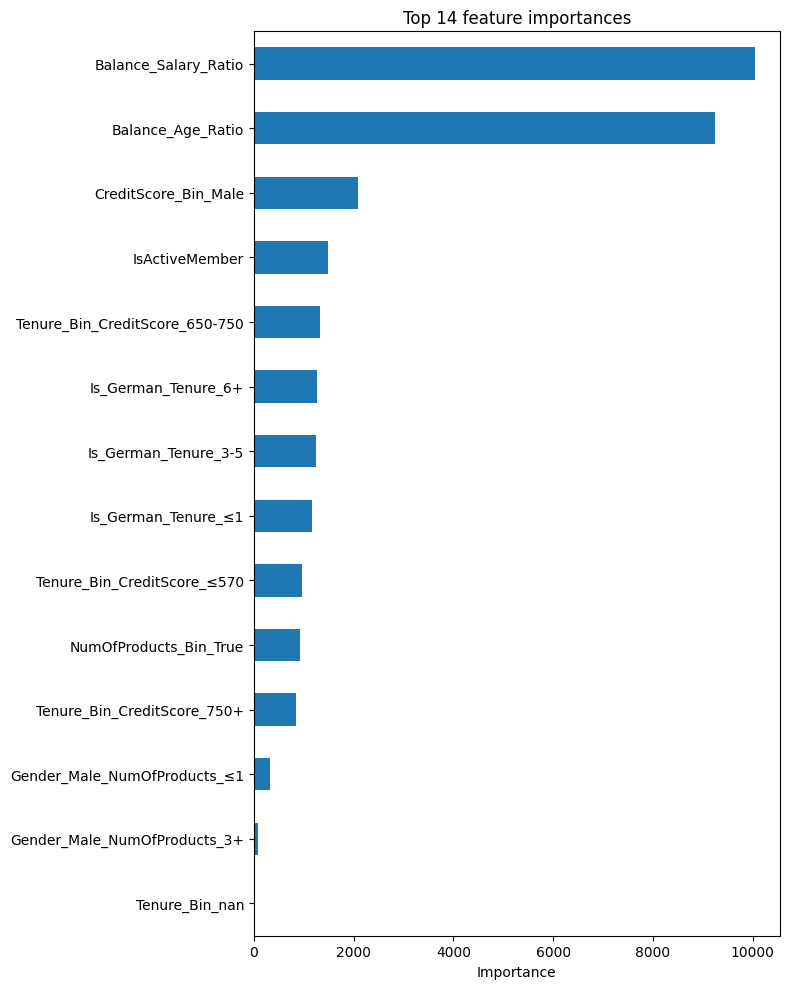

In [16]:
# ...existing code...
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.base import check_is_fitted
from sklearn.exceptions import NotFittedError

def plot_feature_importances(pipe, X, top_n=30, figsize=(8,10)):
    # pipe doit être déjà fit
    model = pipe.named_steps.get('model')
    preproc = pipe.named_steps.get('preprocessing') or pipe.named_steps.get('prep')

    # obtenir noms des features produits par le préprocesseur
    try:
        Xt = preproc.transform(X)
        if hasattr(Xt, "columns"):
            feat_names = list(Xt.columns)
        else:
            feat_names = list(preproc.get_feature_names_out(X.columns))
    except Exception:
        # fallback : utiliser les noms internes du modèle si disponibles
        feat_names = getattr(model, "feature_name_", None)
        if feat_names is None:
            feat_names = list(preproc.get_feature_names_out(X.columns))

    importances = np.array(model.feature_importances_)
    # si mismatch de tailles, tronquer ou étendre les noms
    if len(importances) != len(feat_names):
        min_len = min(len(importances), len(feat_names))
        importances = importances[:min_len]
        feat_names = feat_names[:min_len]

    s = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(top_n)

    plt.figure(figsize=figsize)
    s[::-1].plot.barh(color="C0")
    plt.xlabel("Importance")
    plt.title(f"Top {len(s)} feature importances")
    plt.tight_layout()
    plt.show()

try:
    check_is_fitted(clf)
except NotFittedError:
    clf.fit(X, y)

plot_feature_importances(clf, X)

In [17]:
import optuna

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.2),
        'num_leaves': trial.suggest_int('num_leaves', 16, 256),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-8, 10.0),
        'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-8, 10.0),
        'random_state': int(RANDOM_STATE),
        'n_jobs': 1,   # éviter sur-parallélisme pendant CV
        'verbose': -1,
        'objective': 'binary'
    }

    clf = LGBMClassifier(**params)

    pipe = Pipeline([
        ('preproc', preprocessing),
        # ('smote', SMOTE(random_state=int(RANDOM_STATE))),
        ('clf', clf)
    ])

    # évaluer via CV sur X_tr/y_tr
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='f1', n_jobs=1)
    return float(np.mean(scores))

# lancer l'optimisation
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=int(RANDOM_STATE)))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Best trial:", study.best_trial.value)
print("Best params:", study.best_trial.params)

[I 2025-09-08 18:16:30,129] A new study created in memory with name: no-name-43b6365c-17fd-46f8-a478-5611e3a13f16
Best trial: 0. Best value: 0.509455:   2%|▏         | 1/50 [00:18<15:13, 18.64s/it]

[I 2025-09-08 18:16:48,782] Trial 0 finished with value: 0.5094551211362038 and parameters: {'n_estimators': 594, 'learning_rate': 0.044225442259978466, 'num_leaves': 161, 'max_depth': 8, 'subsample': 0.7694619197355619, 'colsample_bytree': 0.8229470565333281, 'min_child_samples': 47, 'reg_alpha': 1.0615904599004025, 'reg_lambda': 4.7093920302768835}. Best is trial 0 with value: 0.5094551211362038.


Best trial: 0. Best value: 0.509455:   4%|▍         | 2/50 [00:35<14:00, 17.52s/it]

[I 2025-09-08 18:17:05,515] Trial 1 finished with value: 0.5068112153132418 and parameters: {'n_estimators': 445, 'learning_rate': 0.06634115998397347, 'num_leaves': 143, 'max_depth': 8, 'subsample': 0.9702386553170644, 'colsample_bytree': 0.5355180290989434, 'min_child_samples': 13, 'reg_alpha': 1.5204270129130175e-08, 'reg_lambda': 0.31158648353398066}. Best is trial 0 with value: 0.5094551211362038.


Best trial: 0. Best value: 0.509455:   4%|▍         | 2/50 [00:41<16:42, 20.88s/it]


[W 2025-09-08 18:17:11,898] Trial 2 failed with parameters: {'n_estimators': 801, 'learning_rate': 0.10044401164110674, 'num_leaves': 251, 'max_depth': 10, 'subsample': 0.7845917449011727, 'colsample_bytree': 0.8902645881432277, 'min_child_samples': 16, 'reg_alpha': 0.005744988873954126, 'reg_lambda': 1.9506510537765813e-07} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/lb/Projects/Formation_MLPro/competition_kaggle/mlpro-classification-bank-churn-2025/.venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/var/folders/x_/4nrxv6z16rgfs1d44qqn24680000gn/T/ipykernel_70565/1358037378.py", line 29, in objective
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='f1', n_jobs=1)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/lb/Projects/Formation_MLPro/competition_kaggle/mlpro-classifi

KeyboardInterrupt: 

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import KBinsDiscretizer
from modelisation.feature_engineering import ChurnCategories, ChurnProduct, ChurnRatios



numerical = ColumnTransformer(
    transformers=[
        ('ratios', ChurnRatios(scale=True), ['Age', 'Tenure', 'Balance', 'EstimatedSalary']),
        ('product', ChurnProduct(scale=True), ['Age', 'Balance', 'NumOfProducts', 'IsActiveMember', 'CreditScore']),
    ],
    verbose_feature_names_out=False,
    remainder='drop'
)


categorical = ColumnTransformer(
    transformers=[
        ('binning', ChurnCategories(encode=True), ['Gender', 'Geography', 'NumOfProducts', 'CreditScore', 'Age', 'Tenure', 'IsActiveMember']),
        ('balance_transformer', KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='kmeans'), ['Balance'])
    ],
    verbose_feature_names_out=False,
    remainder='drop'
)

preproc = FeatureUnion(
    transformer_list=[
        ('numerical_pipeline', numerical),
        ('categorical_pipeline', categorical)
    ]
)


gb = GradientBoostingClassifier(random_state=42)

pipe = Pipeline([('prep', preproc),
                 ('model', gb)])

pipe.set_params(**{'model__subsample': 0.8,
 'model__n_estimators': 200,
 'model__min_samples_split': 4,
 'model__min_samples_leaf': 2,
 'model__max_depth': 5,
 'model__learning_rate': 0.05})

# param_grid = {
#     'model__n_estimators': [200,300,400],
#     'model__learning_rate': [0.03,0.05,0.1],
#     'model__max_depth': [3,4,5],
#     'model__subsample': [0.8,1.0],
#     'model__min_samples_split':[2,4],
#     'model__min_samples_leaf':[1,2]
# }
param_grid = {
    'model':[
        GradientBoostingClassifier(
            n_estimators=200,
            random_state=42,
            min_samples_split=4,
            min_samples_leaf=2,
            learning_rate=0.003
            ),
        LGBMClassifier(
        objective='binary',
        random_state=RANDOM_STATE,
        n_jobs=0, 
        is_unbalance=True,  
        learning_rate=0.003, 
        num_leaves=225, 
        max_depth=7, 
        n_estimators=300,
        colsample_bytree=0.9,
        subsample=0.8,
        verbose=0,
        )
    ]
}

search = GridSearchCV(
        pipe, param_grid, scoring='f1', cv=4, n_jobs=-1)
search.fit(X_train, y_train)
best_pipe = search.best_estimator_

In [ ]:
import numpy as np
from sklearn.metrics import f1_score


proba = best_pipe.predict_proba(X_test)[:,1]
best_t = np.linspace(0.1,0.9,81)[np.argmax([
           f1_score(y_test, (proba>=t).astype(int))
           for t in np.linspace(0.1,0.9,81)])]

In [ ]:
search.best_params_

In [ ]:
f1_score(y_test, (proba>=best_t))

In [ ]:
search.best_estimator_['model'].feature_name_

In [ ]:
importance_df = pd.DataFrame(search.best_estimator_['model'].feature_importances_, columns=['importance'], index=search.best_estimator_['model'].feature_name_)
importance_df.sort_values(by='importance', ascending=False)